### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 7/04/20236

**1 Caso Práctico: Neurona de McCulloch y Pitts**

1.1 1. Implementación de la MPNeuron

In [5]:
import numpy as np
class MPNeuron:
    def __init__(self):
        self.threshold = None
    def model(self, x):
        # input: [1, 0, 1, 0] [x1, x2, .., xn]
        z = sum(x)
        return (z >= self.threshold)
    def predict(self, X):
        # input: [[1, 0, 1, 0], [1, 0, 1, 1]]
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)


In [6]:
# Instanciamos la neurona
mp_neuron = MPNeuron()

In [7]:
# Establecemos un threshold
mp_neuron.threshold = 4

In [8]:
# Evaluamos diferentes casos de uso
mp_neuron.predict([[1, 0, 0, 0], [1, 1, 1, 1], [1, 1, 1, 0]])


array([False,  True, False])

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git

### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 7/04/20236

# Caso Práctico: Neurona de McCulloch y Pitts
### Aplicando la MPNeurona en un caso práctico real

## 2.1. Conjunto de datos

Esta es una copia de los conjuntos de datos de UCI ML Breast Cancer Wisconsin: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### Descripción de la muestra

Las características de entrada se calculan a partir de una imagen digitalizada de un aspirado de aguja fina (FNA) de una masa mamaria. Describen las características de los núcleos celulares presentes en la imagen.

El plano de separación descrito anteriormente se obtuvo utilizando el método de árbol de múltiples superficies (MSM-T): "Construcción de un árbol de decisión mediante programación lineal".

El programa final utilizado para obtener el plano de separación en el espacio tridimensional es el que describe en [K.P. Bennett y O.L. Mangasarian].

### Lectura de datos

In [114]:
from sklearn.datasets import load_breast_cancer
cancer_mama = load_breast_cancer()

# Datos de entrada
X = cancer_mama.data

# Datos de salida
y = cancer_mama.target

In [115]:
dir(cancer_mama)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [116]:
print(X)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


### Visualización del conjunto de datos

In [117]:
import pandas as pd

df = pd.DataFrame(X, columns=cancer_mama.feature_names)

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [93]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

### División del conjunto de datos

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y, stratify=y)
print("Tamaño de entrenamiento:", len(X_train))
print("Tamaño de prueba:", len(X_test))

Tamaño de entrenamiento: 426
Tamaño de prueba: 143


## Implementación de un aMP Neurona más avanzada

In [147]:
# Importamos las bibliotecas de numpy
import numpy as np
from sklearn.metrics import accuracy_score

class MPNeurona:
    def __init__(self):
        self.threshold = None

    def model(self, x):
        x = sum(x)
        return (x >= self.threshold)

    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)

    def fit(self, X, Y):
        accuracy = {}
        for th in range(X.shape[1] + 1):
            self.threshold = th
            y_pred = self.predict(X)
            accuracy[th] = accuracy_score(y_pred, Y)
        self.threshold = max(accuracy, key=accuracy.get)

Los datos de entrada siguen teniendo problemas debido a que el conjunto de datos las características de entrada contienen valores continuos, sin embargo, la neurona MP solo procesa características de entrada con valores binarios.

[0, 0, 1, 1, 1, 0, 0]
Categories (2, int64): [0 < 1]


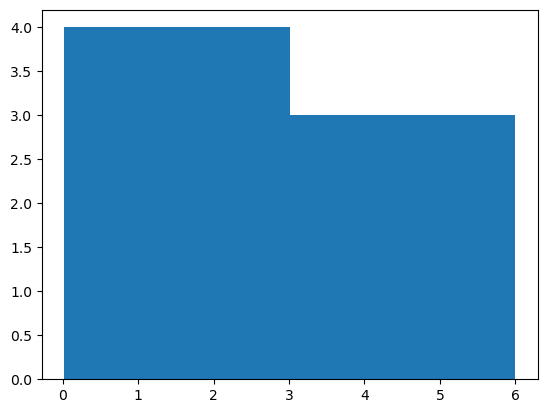

In [148]:
# Antes transformamos los valores en un valor binario
import matplotlib.pyplot as plt
print(pd.cut([0.04,0.3,4,5,6,0.02,0.6], bins=2, labels=[0,1]))
plt.hist([0.04,0.3,4,5,6,0.02,0.6], bins=2)
plt.show()

In [149]:
# Visualizamos las características de entrada para el valor binario
import pandas as pd

# Convertimos a DataFrame para poder usar .apply()
X_train = pd.DataFrame(X_train)
X_test  = pd.DataFrame(X_test)

# Ahora tu código funciona sin cambios
X_train_bin = X_train.apply(pd.cut, bins=2, labels=[1,0])
X_test_bin  = X_test.apply(pd.cut, bins=2, labels=[1,0])

X_train_bin

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
2,0,1,0,0,0,1,1,0,1,1,...,0,1,0,1,1,1,1,0,1,1
102,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,1,1,1,1,1,1
55,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
284,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
511,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
205,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
362,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
502,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1


In [158]:
# Entrenamos el modelo MP
np_neurona = MPNeurona()

np_neurona.fit(X_train_bin.to_numpy(), y_train)

# Obtenemos el threshold
np_neurona.threshold

27

In [160]:
# Realizamos la predicción por una clase de prueba
y_pred = np_neurona.predict(X_test_bin.to_numpy())

In [161]:
y_pred

array([ True, False,  True,  True,  True,  True, False,  True,  True,
        True,  True, False, False,  True,  True,  True, False,  True,
        True,  True,  True,  True, False,  True, False, False, False,
        True,  True,  True, False,  True, False, False,  True,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True, False, False,  True, False, False,  True,
       False,  True, False, False,  True, False,  True, False, False,
        True,  True,  True, False,  True, False, False,  True, False,
        True,  True,  True, False, False, False,  True,  True,  True,
       False,  True,  True, False, False,  True,  True,  True, False,
        True, False,  True, False, False, False,  True,  True,  True,
        True, False, False,  True,  True,  True,  True,  True,  True,
       False,  True, False, False,  True,  True, False,  True, False,
        True,  True, False,  True, False, False,  True,  True, False,
        True,  True,

In [162]:
accuracy_score(y_test, y_pred)

0.8251748251748252

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git